# U-Net Lesion Segmentation

Trains a U-Net to segment the lesion region in the oral cavity images under `artifacts/New Data/{Train,Validation,Test}/<class>/*.json`.

Each JSON is a LabelMe annotation: it embeds the source image as base64 (`imageData`) plus one or more hand-drawn polygons marking the lesion. Almost all shapes are labelled `"Mask"`, with a handful of one-off labels (`SCC`, `Ulcer`, `HPV`, ...) left over from inconsistent annotators. Since the goal here is lesion-vs-background segmentation, not lesion subtyping, every polygon in a file is rasterized into one binary mask regardless of its label text.

The three class folders (`Cancer`, `premalignant`, `Non_inflamatory`/`normal_inflammatory`) are pooled — the model only ever sees "lesion" vs "not lesion".

In [2]:
pip install tf_keras

  Using cached tf_keras-2.21.0-py3-none-any.whl.metadata (1.8 kB)
Using cached tf_keras-2.21.0-py3-none-any.whl (1.7 MB)
   ---------------------------------------- 0.0/350.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/350.6 MB 9.3 MB/s eta 0:00:38
    --------------------------------------- 4.5/350.6 MB 11.7 MB/s eta 0:00:30
    --------------------------------------- 7.3/350.6 MB 12.2 MB/s eta 0:00:29
   - -------------------------------------- 9.7/350.6 MB 11.8 MB/s eta 0:00:29
   - -------------------------------------- 11.8/350.6 MB 11.5 MB/s eta 0:00:30
   - -------------------------------------- 14.4/350.6 MB 11.5 MB/s eta 0:00:30
   - -------------------------------------- 16.8/350.6 MB 11.6 MB/s eta 0:00:29
   -- ------------------------------------- 19.1/350.6 MB 11.5 MB/s eta 0:00:29
   -- ------------------------------------- 21.2/350.6 MB 11.5 MB/s eta 0:00:29
   -- ------------------------------------- 23.9/350.6 MB 11.5 MB/s eta 0:00:29
   --- ------

  You can safely remove it manually.
  You can safely remove it manually.


In [ ]:
import sys
from pathlib import Path

BACKEND_ROOT = Path.cwd().parents[2]
sys.path[:0] = [str(BACKEND_ROOT), str(BACKEND_ROOT / "src")]

import base64
import io
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tf_keras
from PIL import Image, ImageDraw
from tf_keras import layers

random.seed(0)
tf.random.set_seed(0)

IMG_SIZE = 256
BATCH_SIZE = 8

DATA_DIR = BACKEND_ROOT / "artifacts" / "New Data"
# Weights-only, and deliberately not named *.weights.h5 -- tf_keras treats
# that exact suffix as its newer native format, which is just as fragile
# across versions as the full .keras format (it broke in prod with "Layer
# 'conv2d' expected 1 variables, but received 0 variables"). This name
# routes through the legacy, stable HDF5-by-topology loader instead.
MODEL_OUT = BACKEND_ROOT / "artifacts" / "models" / "unet_segmentation_weights.h5"

DATA_DIR

## Decoding a LabelMe sample

`imagePath` in these files points at the annotator's original machine (`../../train/cancer/...`) and doesn't resolve here — the embedded `imageData` is the only usable copy of the image. Polygon points are scaled directly to `IMG_SIZE` before rasterizing, so the mask is drawn at the target resolution instead of being downsampled from a ~3072x4608 original.

In [2]:
def load_sample(json_path, img_size=IMG_SIZE):
    """Decodes a LabelMe JSON into a resized (image, mask) pair.

    All polygon shapes become foreground in one binary mask -- labels are
    inconsistent across annotators and irrelevant to lesion-vs-background.
    """
    ann = json.loads(Path(json_path).read_text())

    image = Image.open(io.BytesIO(base64.b64decode(ann["imageData"]))).convert("RGB")
    image = image.resize((img_size, img_size), Image.BILINEAR)

    sx = img_size / ann["imageWidth"]
    sy = img_size / ann["imageHeight"]

    mask = Image.new("L", (img_size, img_size), 0)
    draw = ImageDraw.Draw(mask)
    for shape in ann["shapes"]:
        points = [(x * sx, y * sy) for x, y in shape["points"]]
        if len(points) >= 3:
            draw.polygon(points, fill=255)

    image = np.asarray(image, dtype=np.float32) / 255.0
    mask = (np.asarray(mask, dtype=np.float32) / 255.0)[..., None]
    return image, mask

## Indexing the splits

The dataset ships pre-split into `Train` / `Validation` / `Test`, each with three class subfolders — pooled here since class doesn't matter for this task.

In [3]:
def json_paths(split):
    return sorted((DATA_DIR / split).glob("*/*.json"))

splits = {name: json_paths(name) for name in ("Train", "Validation", "Test")}
{name: len(paths) for name, paths in splits.items()}

{'Train': 524, 'Validation': 135, 'Test': 84}

## Sanity check

Decode a few random training samples and confirm the rasterized mask lines up with the annotated lesion.

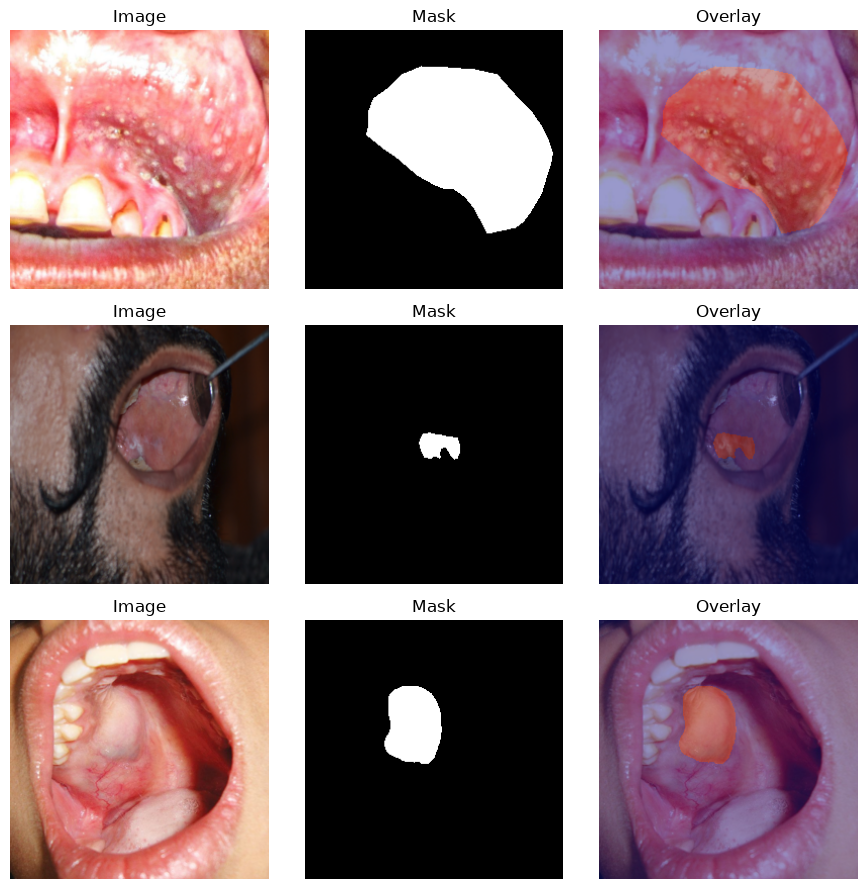

In [4]:
sample_paths = random.sample(splits["Train"], 3)

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for row, p in enumerate(sample_paths):
    image, mask = load_sample(p)
    axes[row, 0].imshow(image); axes[row, 0].set_title("Image"); axes[row, 0].axis("off")
    axes[row, 1].imshow(mask[..., 0], cmap="gray"); axes[row, 1].set_title("Mask"); axes[row, 1].axis("off")
    axes[row, 2].imshow(image); axes[row, 2].imshow(mask[..., 0], cmap="jet", alpha=0.4)
    axes[row, 2].set_title("Overlay"); axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

## Converting annotations to image/mask files

Everything above decodes straight from the LabelMe JSON on demand. That means re-doing the base64 decode and polygon rasterization on every single epoch, and there's nothing on disk you can just open and look at. This materializes each entry once as a plain image (`.jpg`) and mask (`.png`) pair under `artifacts/New Data/converted/<split>/{images,masks}/`, reusing `load_sample` for the decode. The training pipeline below reads these files directly.

In [5]:
CONVERTED_DIR = DATA_DIR / "converted"


def convert_split(split):
    images_dir = CONVERTED_DIR / split / "images"
    masks_dir = CONVERTED_DIR / split / "masks"
    images_dir.mkdir(parents=True, exist_ok=True)
    masks_dir.mkdir(parents=True, exist_ok=True)

    for json_path in splits[split]:
        image, mask = load_sample(json_path)
        stem = json_path.stem
        Image.fromarray((image * 255).astype(np.uint8)).save(images_dir / f"{stem}.jpg", quality=95)
        Image.fromarray((mask[..., 0] * 255).astype(np.uint8)).save(masks_dir / f"{stem}.png")

    return sorted(images_dir.glob("*.jpg"))


converted_images = {split: convert_split(split) for split in splits}
{split: len(paths) for split, paths in converted_images.items()}

{'Train': 524, 'Validation': 135, 'Test': 84}

## tf.data pipelines

Images and masks now live on disk as plain files, so this loads them with native tf.io/tf.image ops (fast, parallelizable) instead of a Python generator. The training pipeline adds random flips, applied identically to image and mask so they stay aligned.

In [6]:
def make_dataset(image_paths, img_size=IMG_SIZE, batch_size=BATCH_SIZE, augment=False, shuffle=False):
    mask_paths = [str(p.parents[1] / "masks" / f"{p.stem}.png") for p in image_paths]
    image_paths = [str(p) for p in image_paths]

    def load(image_path, mask_path):
        image = tf.io.decode_jpeg(tf.io.read_file(image_path), channels=3)
        image = tf.cast(image, tf.float32) / 255.0
        image.set_shape((img_size, img_size, 3))

        mask = tf.io.decode_png(tf.io.read_file(mask_path), channels=1)
        mask = tf.cast(mask, tf.float32) / 255.0
        mask.set_shape((img_size, img_size, 1))
        return image, mask

    ds = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))
    if shuffle:
        ds = ds.shuffle(len(image_paths), seed=0, reshuffle_each_iteration=True)

    ds = ds.map(load, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        def flip(image, mask):
            if tf.random.uniform(()) > 0.5:
                image, mask = tf.image.flip_left_right(image), tf.image.flip_left_right(mask)
            if tf.random.uniform(()) > 0.5:
                image, mask = tf.image.flip_up_down(image), tf.image.flip_up_down(mask)
            return image, mask

        ds = ds.map(flip, num_parallel_calls=tf.data.AUTOTUNE)

    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


train_ds = make_dataset(converted_images["Train"], augment=True, shuffle=True)
val_ds = make_dataset(converted_images["Validation"])
test_ds = make_dataset(converted_images["Test"])

## The U-Net

A from-scratch encoder-decoder with skip connections: four downsampling stages, a bottleneck, then four upsampling stages that concatenate the matching encoder features. BatchNorm after every conv for a dataset this small.

In [ ]:
from pipeline.unet_architecture import build_unet

# Defined in pipeline/unet_architecture.py, not inline here, so training and
# serving (pipeline/model_loader.py) always build the exact same graph --
# weights-only loading requires that match.
model = build_unet(IMG_SIZE)
model.summary()

## Loss and metrics

Lesions typically cover a minority of the image, so plain binary crossentropy alone tends to bias toward predicting background everywhere. Combining it with a Dice term keeps the model honest about foreground overlap; Dice and IoU are also reported as threshold-aware metrics since they matter more here than raw pixel accuracy.

In [8]:
def dice_coefficient(y_true, y_pred, smooth=1.0):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)


def bce_dice_loss(y_true, y_pred):
    bce = tf.reduce_mean(tf_keras.losses.binary_crossentropy(y_true, y_pred))
    return bce + (1.0 - dice_coefficient(y_true, y_pred))


model.compile(
    optimizer=tf_keras.optimizers.Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=[dice_coefficient, tf_keras.metrics.BinaryIoU(target_class_ids=[1], threshold=0.5)],
)

## Training

~524 training images is small for a from-scratch U-Net, so training watches `val_dice_coefficient` (threshold-free, unlike accuracy) for checkpointing, with early stopping and LR decay on plateau to avoid overfitting the minority classes (`Cancer`, `Non_inflamatory`).

In [ ]:
MODEL_OUT.parent.mkdir(parents=True, exist_ok=True)

callbacks = [
    tf_keras.callbacks.ModelCheckpoint(
        str(MODEL_OUT),
        monitor="val_dice_coefficient",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
    ),
    tf_keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    tf_keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5),
]

history = model.fit(train_ds, validation_data=val_ds, epochs=60, callbacks=callbacks)

## Training curves

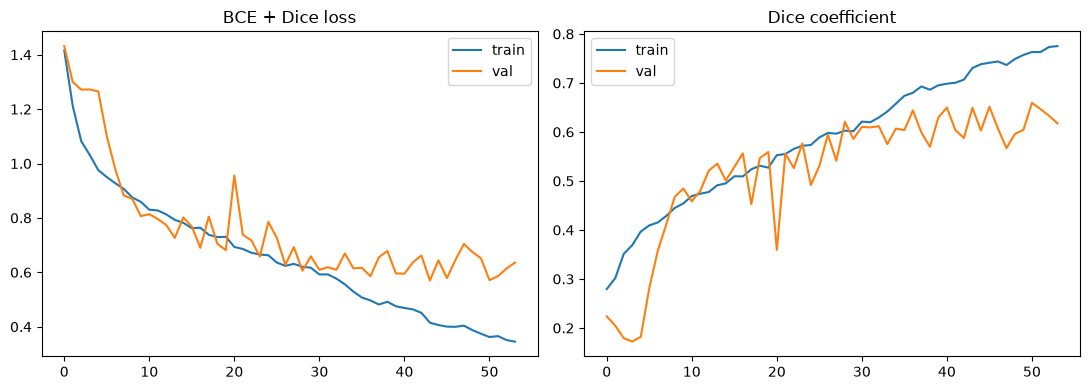

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("BCE + Dice loss"); axes[0].legend()

axes[1].plot(history.history["dice_coefficient"], label="train")
axes[1].plot(history.history["val_dice_coefficient"], label="val")
axes[1].set_title("Dice coefficient"); axes[1].legend()

plt.tight_layout()
plt.show()

## Test set evaluation

In [11]:
test_loss, test_dice, test_iou = model.evaluate(test_ds)
print(f"loss: {test_loss:.4f}  dice: {test_dice:.4f}  IoU: {test_iou:.4f}")

11/11 [==============================] - 2s 175ms/step - loss: 0.6519 - dice_coefficient: 0.5751 - binary_io_u: 0.4937
loss: 0.6519  dice: 0.5751  IoU: 0.4937


## Sample predictions

Ground truth vs. predicted mask (thresholded at 0.5) on a few held-out test images.

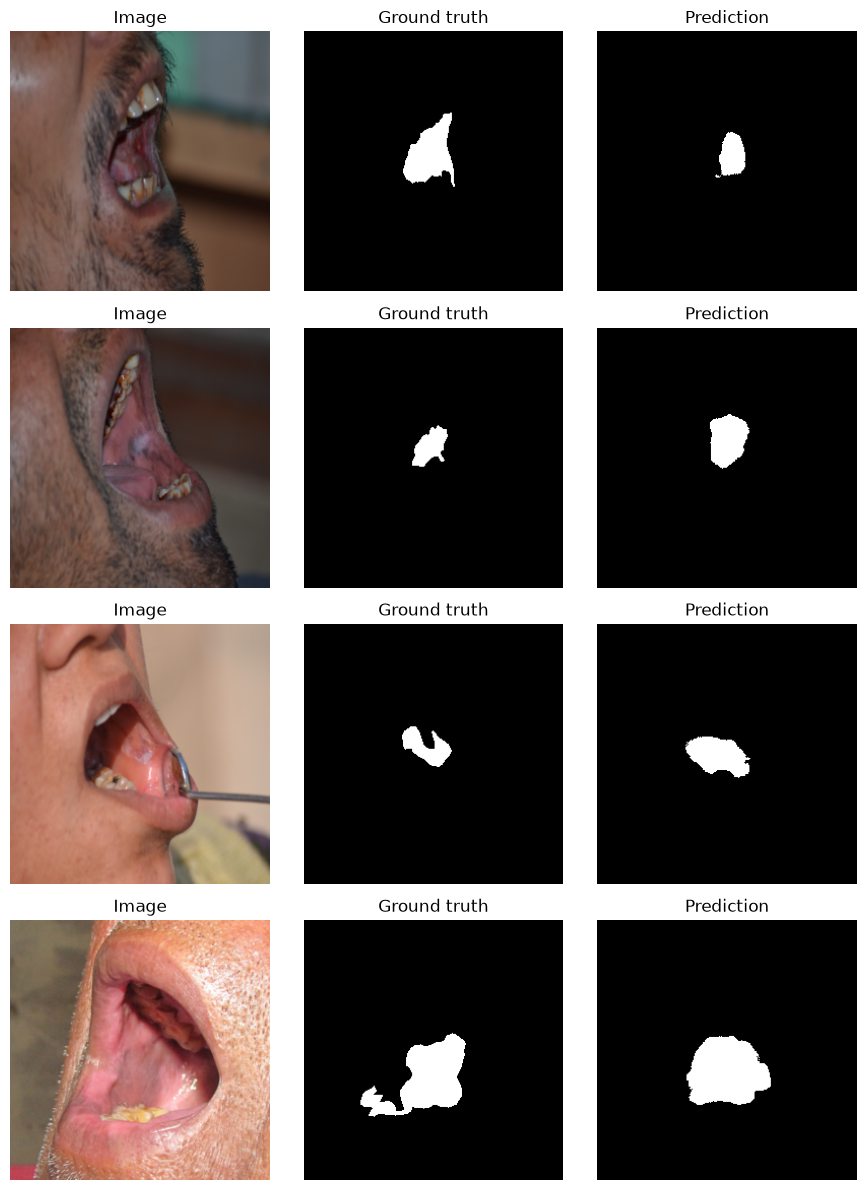

In [12]:
sample_paths = random.sample(splits["Test"], 4)

fig, axes = plt.subplots(len(sample_paths), 3, figsize=(9, 3 * len(sample_paths)))
for row, p in enumerate(sample_paths):
    image, mask = load_sample(p)
    pred = model.predict(image[None, ...], verbose=0)[0, ..., 0]

    axes[row, 0].imshow(image); axes[row, 0].set_title("Image"); axes[row, 0].axis("off")
    axes[row, 1].imshow(mask[..., 0], cmap="gray"); axes[row, 1].set_title("Ground truth"); axes[row, 1].axis("off")
    axes[row, 2].imshow(pred > 0.5, cmap="gray"); axes[row, 2].set_title("Prediction"); axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

## Scoring an arbitrary image

The cells above only ever run on dataset entries that carry a LabelMe JSON (image + ground-truth mask). This does the same job for any plain image file — no annotation required — and writes the result to disk as a PNG instead of just plotting it inline.

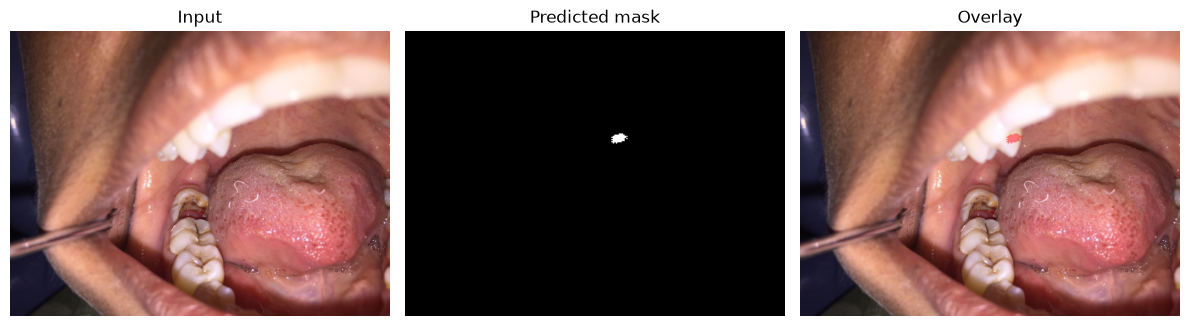

Saved: d:\Hemanth\Prayaas\backend\artifacts\Old Data\CANCER\001_segmented.png


WindowsPath('d:/Hemanth/Prayaas/backend/artifacts/Old Data/CANCER/001_segmented.png')

In [15]:
def segment_image(image_path, output_path=None, threshold=0.5):
    """Runs the trained U-Net on any image file and saves an overlay PNG.

    Unlike load_sample, this takes a plain photo -- no LabelMe JSON / ground
    truth mask needed -- for scoring new, unannotated images.
    """
    image_path = Path(image_path)
    original = Image.open(image_path).convert("RGB")
    resized = original.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)

    array = np.asarray(resized, dtype=np.float32) / 255.0
    pred = model.predict(array[None, ...], verbose=0)[0, ..., 0]

    # Upscale the predicted mask back to the original resolution for the overlay.
    mask = (pred > threshold).astype(np.uint8) * 255
    mask_img = Image.fromarray(mask).resize(original.size, Image.NEAREST)

    red_layer = Image.new("RGBA", original.size, (255, 0, 0, 0))
    red_layer.putalpha(mask_img.point(lambda p: 120 if p > 0 else 0))
    overlay = Image.alpha_composite(original.convert("RGBA"), red_layer).convert("RGB")

    if output_path is None:
        output_path = image_path.with_name(f"{image_path.stem}_segmented.png")
    output_path = Path(output_path)
    overlay.save(output_path)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(original); axes[0].set_title("Input"); axes[0].axis("off")
    axes[1].imshow(mask_img, cmap="gray"); axes[1].set_title("Predicted mask"); axes[1].axis("off")
    axes[2].imshow(overlay); axes[2].set_title("Overlay"); axes[2].axis("off")
    plt.tight_layout()
    plt.show()

    print(f"Saved: {output_path}")
    return output_path


# Example: score one of the existing classifier's images (raw_data was renamed to "Old Data").
segment_image(BACKEND_ROOT / "artifacts" / "Old Data" / "CANCER" / "001.jpeg")

# A couple more to try:
# segment_image(BACKEND_ROOT / "artifacts" / "Old Data" / "NON CANCER" / "001.jpeg")
# segment_image(BACKEND_ROOT / "artifacts" / "New Data" / "converted" / "Test" / "images" / "premalignant_0001.jpg")

## Notes

- ~740 annotated images total, pooled across 3 classes, is a small dataset for a from-scratch U-Net — expect stronger performance on `premalignant` (the majority class, ~450 images) than `Cancer`/`Non_inflamatory` (~150 each).
- If Dice plateaus too early, the usual next steps are: more aggressive augmentation (rotation, brightness/contrast jitter), or swapping the from-scratch encoder for a pretrained one (e.g. MobileNetV2) via transfer learning — the latter tends to matter most when labelled data is this limited.
- The saved model lives at `artifacts/models/unet_segmentation.keras`, separate from the existing classifier (`model_weights.keras`) — nothing here touches the classification pipeline.